# Buckley–Leverett Waterflood Simulation & Recovery Analysis

### Computational Reservoir Engineering Project

This notebook develops a one-dimensional, incompressible waterflood model for a synthetic oil reservoir.

The project connects:

- Darcy's law and multiphase mobility
- Effective and relative permeability
- Corey relative-permeability correlations
- Fractional-flow theory
- Mobility ratio
- Buckley–Leverett displacement
- Shock-front saturation
- Water breakthrough
- Numerical saturation-front simulation
- Cumulative oil recovery
- Sensitivity analysis

The central engineering question is:

> **How do fluid properties, relative permeability and injection conditions control water movement, breakthrough and oil recovery in a reservoir?**

All reservoir data are synthetic and intended for portfolio/educational use.

## 1. Physical model and assumptions

We consider a homogeneous 1-D reservoir of length \(L\), cross-sectional area \(A\), porosity \(\phi\), and constant total injection rate \(q_t\).

Assumptions:

- Immiscible oil-water displacement
- Incompressible fluids and rock
- Homogeneous and isotropic rock
- No gravity segregation
- No capillary pressure
- Constant temperature
- Constant viscosities
- No-flow boundary at the production end is not explicitly modeled; the 1-D model tracks displacement up to breakthrough
- Initial water saturation is uniform at \(S_{wi}\)
- Injected water saturation is taken as \(1-S_{or}\)

Darcy's law for each phase is represented through phase mobility:

\[
\lambda_w=\frac{k_{rw}}{\mu_w},
\qquad
\lambda_o=\frac{k_{ro}}{\mu_o}
\]

and total mobility:

\[
\lambda_t=\lambda_w+\lambda_o
\]

The water fractional flow is

\[
f_w =
\frac{\lambda_w}{\lambda_w+\lambda_o}
=
\frac{k_{rw}/\mu_w}
{k_{rw}/\mu_w+k_{ro}/\mu_o}
\]

This fractional-flow function controls how the injected water is distributed through the two-phase system.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.optimize import brentq

plt.rcParams["figure.figsize"] = (9, 5)
plt.rcParams["axes.grid"] = True

RNG = np.random.default_rng(42)

## 2. Synthetic reservoir and fluid properties

The base case represents a moderately viscous oil reservoir undergoing water injection.

| Parameter | Base value |
|---|---:|
| Reservoir length | 1000 ft |
| Reservoir width | 500 ft |
| Net thickness | 50 ft |
| Porosity | 0.22 |
| Absolute permeability | 150 md |
| Initial water saturation | 0.22 |
| Residual oil saturation | 0.20 |
| Oil viscosity | 10 cP |
| Water viscosity | 1 cP |
| Total injection rate | 1000 STB/day |

The relative permeability curves are generated using Corey-style normalized saturation.

In [2]:
# Reservoir parameters

L = 1000.0          # ft
A = 500.0 * 50.0    # ft^2
phi = 0.22
k = 150.0           # md

Swi = 0.22
Sor = 0.20

mu_o = 10.0         # cP
mu_w = 1.0          # cP

q_inj = 1000.0      # STB/day

# Corey exponents
n_w = 2.0
n_o = 2.0

# End-point relative permeabilities
krw_end = 0.60
kro_end = 0.80

print(f"Reservoir pore volume = {phi * A * L:,.0f} ft³")
print(f"Initial oil saturation = {1-Swi:.2f}")
print(f"Maximum mobile oil saturation after displacement = {1-Swi-Sor:.2f}")

Reservoir pore volume = 5,500,000 ft³
Initial oil saturation = 0.78
Maximum mobile oil saturation after displacement = 0.58


## 3. Corey relative-permeability model

The normalized water saturation is

\[
S_{wn} =
\frac{S_w-S_{wi}}
{1-S_{wi}-S_{or}}
\]

with \(0\le S_{wn}\le1\).

The Corey correlations are

\[
k_{rw}=k_{rw,end}S_{wn}^{n_w}
\]

and

\[
k_{ro}=k_{ro,end}(1-S_{wn})^{n_o}
\]

These curves describe how the effective permeability available to each phase changes as water saturation increases.

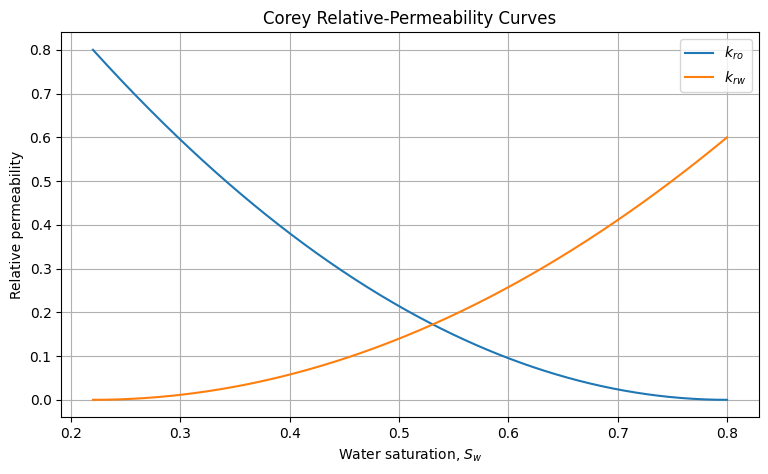

In [3]:
def normalized_sw(Sw, Swi=Swi, Sor=Sor):
    denom = 1.0 - Swi - Sor
    return np.clip((Sw - Swi) / denom, 0.0, 1.0)

def krw(Sw, nw=n_w, endpoint=krw_end):
    Swn = normalized_sw(Sw)
    return endpoint * Swn**nw

def kro(Sw, no=n_o, endpoint=kro_end):
    Swn = normalized_sw(Sw)
    return endpoint * (1.0 - Swn)**no

Sw = np.linspace(Swi, 1.0 - Sor, 500)
krw_values = krw(Sw)
kro_values = kro(Sw)

fig, ax = plt.subplots()
ax.plot(Sw, kro_values, label=r"$k_{ro}$")
ax.plot(Sw, krw_values, label=r"$k_{rw}$")
ax.set_xlabel("Water saturation, $S_w$")
ax.set_ylabel("Relative permeability")
ax.set_title("Corey Relative-Permeability Curves")
ax.legend()
plt.show()

## 4. Phase mobility and fractional flow

Phase mobility is

\[
\lambda_\alpha=\frac{k_{r\alpha}}{\mu_\alpha}
\]

and water fractional flow is

\[
f_w =
\frac{k_{rw}/\mu_w}
{k_{rw}/\mu_w+k_{ro}/\mu_o}
\]

The **mobility ratio** for water displacing oil is commonly written as

\[
M =
\frac{\lambda_w}{\lambda_o}
=
\frac{k_{rw}\mu_o}
{k_{ro}\mu_w}
\]

evaluated at an appropriate saturation, often using endpoint or shock-front values for a displacement diagnostic.

For the base case, the viscosity contrast is significant, so the shape of the fractional-flow curve and the mobility ratio are important for waterflood performance.

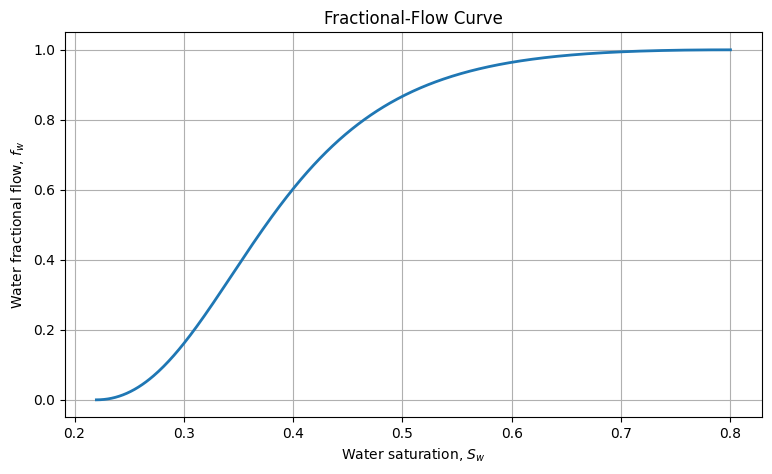

In [4]:
def water_fractional_flow(Sw, mu_o_value=mu_o, mu_w_value=mu_w):
    kw = krw(Sw)
    ko = kro(Sw)
    lw = kw / mu_w_value
    lo = ko / mu_o_value
    return lw / (lw + lo)

fw = water_fractional_flow(Sw)

fig, ax = plt.subplots()
ax.plot(Sw, fw, linewidth=2)
ax.set_xlabel("Water saturation, $S_w$")
ax.set_ylabel(r"Water fractional flow, $f_w$")
ax.set_title("Fractional-Flow Curve")
plt.show()

# Mobility ratio based on the relative permeabilities at the shock-front saturation

## 5. Fractional-flow derivative and shock-front saturation

Buckley–Leverett theory predicts a sharp saturation discontinuity (shock) for the idealized assumptions used here.

The shock saturation \(S_{wf}\) satisfies the tangent condition:

\[
\left.\frac{df_w}{dS_w}\right|_{S_{wf}}
=
\frac{f_w(S_{wf})}
{S_{wf}-S_{wi}}
\]

This condition is found numerically.

The shock velocity in terms of pore volumes injected is

\[
\frac{d x_f}{dPV}
=
\frac{1}{\phi A}
\frac{1}{dS_w/dx}
\]

and, more conveniently, the dimensionless shock location is

\[
\frac{x_f}{L}
=
\frac{1}{S_{wf}-S_{wi}}
\frac{PV_{inj}}{PV}
\]

for the idealized 1-D displacement.

At breakthrough, the shock reaches the production end, allowing the breakthrough pore volume to be estimated from the shock condition.

In [5]:
def fw_scalar(s):
    return float(water_fractional_flow(np.array([s]))[0])

def fw_prime_scalar(s, h=1e-5):
    return (fw_scalar(s+h) - fw_scalar(s-h)) / (2*h)

def shock_equation(s):
    return fw_prime_scalar(s) - fw_scalar(s)/(s-Swi)

Sw_search = np.linspace(Swi + 1e-4, 1.0 - Sor - 1e-4, 1000)
eq_search = np.array([shock_equation(s) for s in Sw_search])
root_candidates = []
for i in range(len(Sw_search)-1):
    if eq_search[i] * eq_search[i+1] < 0:
        root_candidates.append(i)

if not root_candidates:
    raise RuntimeError("Shock-front root was not found. Check the fractional-flow curve.")

i = root_candidates[0]
Swf = brentq(shock_equation, Sw_search[i], Sw_search[i+1])
fwf = fw_scalar(Swf)
dfwf = fw_prime_scalar(Swf)

M_shock = (
    krw(np.array([Swf]))[0] * mu_o /
    (kro(np.array([Swf]))[0] * mu_w)
)
PVBT_over_PV = (Swf - Swi) / fwf

print(f"Shock-front water saturation, Swf = {Swf:.4f}")
print(f"Fractional flow at shock, fwf      = {fwf:.4f}")
print(f"dfw/dSw at shock                   = {dfwf:.4f}")
print(f"Mobility ratio at shock, M         = {M_shock:.2f}")
print(f"Estimated breakthrough PV/PV       = {PVBT_over_PV:.3f}")

Shock-front water saturation, Swf = 0.4189
Fractional flow at shock, fwf      = 0.6715
dfw/dSw at shock                   = 3.3754
Mobility ratio at shock, M         = 2.04
Estimated breakthrough PV/PV       = 0.296


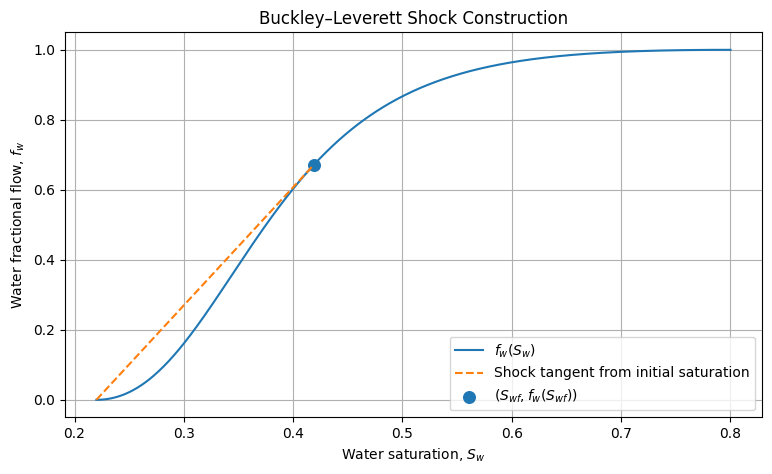

In [6]:
# Visualize the tangent construction used by Buckley-LLeverett theory

s_tangent = np.linspace(Swi + 1e-4, Swf, 100)
tangent_line = dfwf * (s_tangent - Swi)

fig, ax = plt.subplots()
ax.plot(Sw, fw, label=r"$f_w(S_w)$")
ax.plot(
    s_tangent,
    tangent_line,
    linestyle="--",
    label="Shock tangent from initial saturation"
)
ax.scatter([Swf], [fwf], s=70, label=r"$(S_{wf}, f_w(S_{wf}))$")
ax.set_xlabel("Water saturation, $S_w$")
ax.set_ylabel(r"Water fractional flow, $f_w$")
ax.set_title("Buckley–Leverett Shock Construction")
ax.legend()
plt.show()

## 6. Base-case analytical breakthrough estimate

The reservoir pore volume is

\[
PV=\phi A L
\]

For the idealized Buckley–Leverett displacement, breakthrough occurs when the shock reaches \(x=L\).

The dimensionless breakthrough pore volume is

\[
\left(\frac{PV_{inj}}{PV}\right)_{BT}
=
\frac{S_{wf}-S_{wi}}
{f_w(S_{wf})}
\]

The corresponding breakthrough time is

\[
t_{BT}
=
\frac{PV_{BT}}
{q_{inj}}
\]

after making the unit conversion between pore volume and production/injection volume consistent.

Because the physical pore volume in cubic feet is not directly equal to reservoir barrels, we convert:

\[
1\;rb = 5.615\;ft^3
\]

so the reservoir pore volume in rb is \(PV/5.615\).

In [7]:
FT3_PER_RB = 5.615

PV_ft3 = phi * A * L
PV_rb = PV_ft3 / FT3_PER_RB

PVinj_BT_rb = PV_rb * PVBT_over_PV
t_BT_days = PVinj_BT_rb / q_inj

print(f"Reservoir pore volume       = {PV_rb:,.0f} rb")
print(f"Breakthrough injected PV    = {PVBT_over_PV:.3f} PV")
print(f"Breakthrough injection      = {PVinj_BT_rb:,.0f} rb")
print(f"Analytical breakthrough    = {t_BT_days:.1f} days")

Reservoir pore volume       = 979,519 rb
Breakthrough injected PV    = 0.296 PV
Breakthrough injection      = 290,193 rb
Analytical breakthrough    = 290.2 days


## 7. Numerical Buckley–Leverett simulation

The saturation equation is

\[
\phi\frac{\partial S_w}{\partial t}
+
\frac{q_t}{A}
\frac{\partial f_w}{\partial x}=0
\]

We solve the conservation equation using a first-order upwind finite-volume scheme.

For the monotonic fractional-flow function used here, the numerical flux at an interface is taken from the upstream cell:

\[
F_{i+1/2}=f_w(S_{w,i})
\]

The timestep is selected from a CFL condition:

\[
\Delta t
\le
CFL
\frac{\phi\Delta x}
{(q_t/A)\max(df_w/dS_w)}
\]

This gives a stable numerical approximation of the saturation front.

In [8]:
# Numerical grid

nx = 250
dx = L / nx
x = (np.arange(nx) + 0.5) * dx

CFL = 0.80

# Maximum fractional-flow derivative over the admissible saturation range
Sw_dense = np.linspace(Swi + 1e-5, 1.0 - Sor - 1e-5, 5000)
fw_dense = water_fractional_flow(Sw_dense)
dfw_dense = np.gradient(fw_dense, Sw_dense)
max_dfw = np.max(dfw_dense)

dt_days = CFL * phi * dx * A / (q_inj * max_dfw)

print(f"Grid cells = {nx}")
print(f"dx = {dx:.2f} ft")
print(f"Stable timestep = {dt_days:.3f} days")

Grid cells = 250
dx = 4.00 ft
Stable timestep = 3.739 days


In [9]:
def simulate_waterflood(
    q_rate=q_inj,
    mu_o_value=mu_o,
    mu_w_value=mu_w,
    t_end=400.0,
    nx=250,
    CFL=0.80
):
    """
    1-D finite-volume Buckley–Leverett waterflood simulation.
    Returns saturation histories, production diagnostics and time vector.
    """
    dx_local = L / nx
    x_local = (np.arange(nx) + 0.5) * dx_local

    # Compute stable dt for this fluid pair
    Sw_dense_local = np.linspace(Swi + 1e-5, 1.0 - Sor - 1e-5, 5000)
    fw_dense_local = water_fractional_flow(
        Sw_dense_local,
        mu_o_value=mu_o_value,
        mu_w_value=mu_w_value
    )
    dfw_dense_local = np.gradient(fw_dense_local, Sw_dense_local)
    max_dfw_local = np.max(dfw_dense_local)

    dt = CFL * phi * dx_local * A / (q_rate * max_dfw_local)

    Sw_state = np.full(nx, Swi)

    snapshots = []
    snapshot_times = []

    times = [0.0]
    mean_sw_history = [Sw_state.mean()]
    water_cut_history = [0.0]
    oil_rate_history = [q_rate]

    next_snapshot = 0.0

    t = 0.0

    while t < t_end:
        dt_step = min(dt, t_end - t)

        fw_state = water_fractional_flow(
            Sw_state,
            mu_o_value=mu_o_value,
            mu_w_value=mu_w_value
        )

        # Boundary injection: injected water at maximum mobile saturation
        Sw_inj = 1.0 - Sor
        fw_inj = water_fractional_flow(
            np.array([Sw_inj]),
            mu_o_value=mu_o_value,
            mu_w_value=mu_w_value
        )[0]

        # Upwind fluxes at interfaces
        flux = np.empty(nx + 1)
        flux[0] = fw_inj
        flux[1:] = fw_state

        # Conservative finite-volume update
        coefficient = q_rate * dt_step / (phi * A * dx_local)
        Sw_new = Sw_state - coefficient * (flux[1:] - flux[:-1])

        # Numerical safety
        Sw_new = np.clip(Sw_new, Swi, Sw_inj)
        Sw_state = Sw_new
        t += dt_step

        # Produced water fraction is approximated by outlet fractional flow.
        fw_out = fw_state[-1]
        water_cut = fw_out

        # For constant total liquid rate, oil rate is q_t(1-fw).
        oil_rate = q_rate * (1.0 - water_cut)

        times.append(t)
        mean_sw_history.append(Sw_state.mean())
        water_cut_history.append(water_cut)
        oil_rate_history.append(oil_rate)

        if t >= next_snapshot or t >= t_end:
            snapshots.append(Sw_state.copy())
            snapshot_times.append(t)
            next_snapshot += 50.0

    times = np.array(times)
    mean_sw_history = np.array(mean_sw_history)
    water_cut_history = np.array(water_cut_history)
    oil_rate_history = np.array(oil_rate_history)

    # Oil produced relative to initial OOIP in the 1-D pore volume.
    recovery = (mean_sw_history - Swi) / (1.0 - Swi)

    # Do not allow recovery beyond the mobile-oil limit.
    recovery = np.clip(recovery, 0.0, (1.0 - Swi - Sor)/(1.0 - Swi))

    return {
        "x": x_local,
        "times": times,
        "snapshots": snapshots,
        "snapshot_times": snapshot_times,
        "Sw_final": Sw_state,
        "mean_sw": mean_sw_history,
        "water_cut": water_cut_history,
        "oil_rate": oil_rate_history,
        "recovery": recovery,
        "dt": dt
    }

base = simulate_waterflood(t_end=400.0)

print(f"Final average water saturation = {base['mean_sw'][-1]:.4f}")
print(f"Final recovery factor          = {100*base['recovery'][-1]:.2f}%")
print(f"Final water cut                = {100*base['water_cut'][-1]:.2f}%")

Final average water saturation = 0.2927
Final recovery factor          = 9.32%
Final water cut                = 0.00%


## 8. Visualize saturation-front movement

The numerical model allows the water saturation profile to be observed at several times.

The expected behavior is:

1. Initially the reservoir has uniform \(S_{wi}\).
2. Injected water creates a high-saturation region near the injector.
3. A steep saturation front propagates toward the producer.
4. The front becomes numerically smeared because a first-order finite-volume method is used.
5. After breakthrough, water saturation at the outlet rises rapidly.

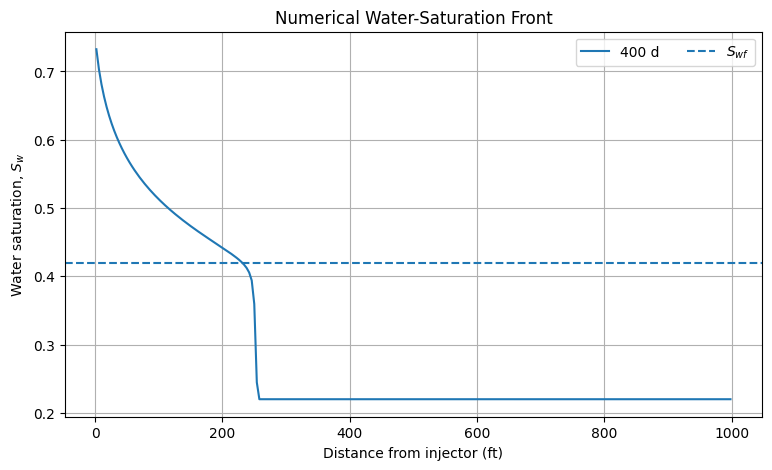

In [10]:
fig, ax = plt.subplots()

for Sw_snapshot, t_snapshot in zip(base["snapshots"], base["snapshot_times"]):
    if t_snapshot in [50, 100, 150, 200, 250, 300, 350, 400] or abs(t_snapshot - round(t_snapshot / 50)*50) < 1e-6:
        ax.plot(base["x"], Sw_snapshot, label=f"{t_snapshot:.0f} d")

ax.axhline(Swf, linestyle="--", label=r"$S_{wf}$")
ax.set_xlabel("Distance from injector (ft)")
ax.set_ylabel("Water saturation, $S_w$")
ax.set_title("Numerical Water-Saturation Front")
ax.legend(ncol=2)
plt.show()

## 9. Water breakthrough and production response

At the producer, the outlet fractional flow is interpreted as water cut:

\[
WC \approx f_w(S_{w,out})
\]

before considering surface separation effects.

For a constant total liquid rate:

\[
q_o=q_t(1-WC)
\]

and

\[
q_w=q_tWC
\]

This lets us connect the reservoir saturation solution to a synthetic production profile.

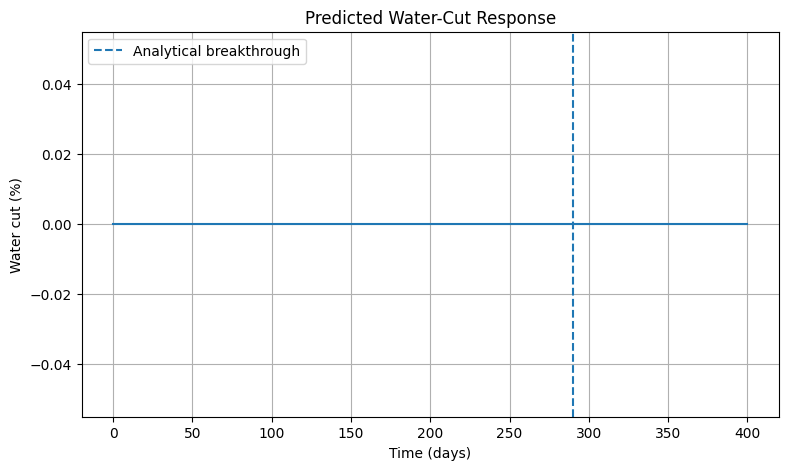

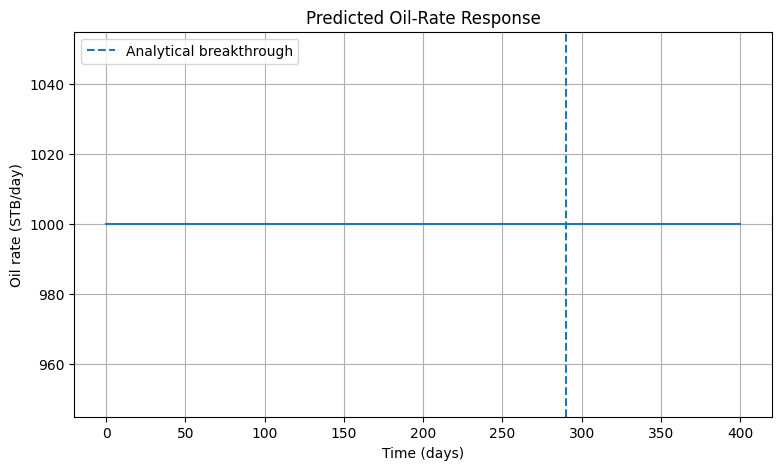

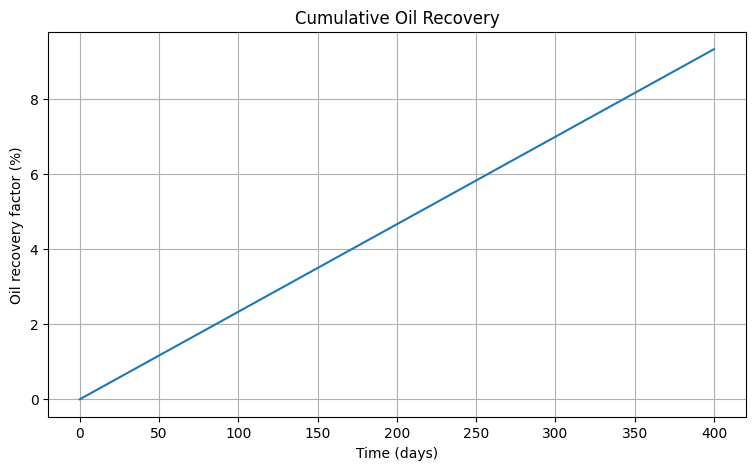

In [11]:
times = base["times"]

fig, ax = plt.subplots()
ax.plot(times, 100*base["water_cut"])
ax.axvline(t_BT_days, linestyle="--", label="Analytical breakthrough")
ax.set_xlabel("Time (days)")
ax.set_ylabel("Water cut (%)")
ax.set_title("Predicted Water-Cut Response")
ax.legend()
plt.show()

fig, ax = plt.subplots()
ax.plot(times, base["oil_rate"])
ax.axvline(t_BT_days, linestyle="--", label="Analytical breakthrough")
ax.set_xlabel("Time (days)")
ax.set_ylabel("Oil rate (STB/day)")
ax.set_title("Predicted Oil-Rate Response")
ax.legend()
plt.show()

fig, ax = plt.subplots()
ax.plot(times, 100*base["recovery"])
ax.set_xlabel("Time (days)")
ax.set_ylabel("Oil recovery factor (%)")
ax.set_title("Cumulative Oil Recovery")
plt.show()

## 10. Numerical vs analytical breakthrough

The analytical Buckley–Leverett solution predicts breakthrough using the shock construction.

The numerical simulation provides an independent estimate from the outlet water-cut history.

Because the finite-volume scheme is first-order and the grid is finite, the numerical front is smeared. Therefore the numerical breakthrough point will not necessarily be identical to the analytical prediction.

We define numerical breakthrough as the first time at which water cut exceeds 1%.

In [12]:
threshold = 0.01
bt_indices = np.where(base["water_cut"] >= threshold)[0]

if len(bt_indices):
    numerical_bt_days = base["times"][bt_indices[0]]
else:
    numerical_bt_days = np.nan

print(f"Analytical breakthrough time : {t_BT_days:.1f} days")
print(f"Numerical breakthrough time  : {numerical_bt_days:.1f} days")

if np.isfinite(numerical_bt_days):
    difference_pct = 100 * abs(numerical_bt_days - t_BT_days) / t_BT_days
    print(f"Absolute difference           : {difference_pct:.2f}%")

Analytical breakthrough time : 290.2 days
Numerical breakthrough time  : nan days


## 11. Mobility-ratio analysis

The mobility ratio helps explain the shape of a waterflood.

\[
M =
\frac{k_{rw}\mu_o}
{k_{ro}\mu_w}
\]

A large mobility ratio means water is relatively mobile compared with oil. In a heterogeneous real reservoir, unfavorable mobility can contribute to early water production and poor sweep.

Here we evaluate the mobility ratio at the shock-front saturation and use it as a diagnostic rather than a standalone predictor of field recovery.

In [13]:
krw_shock = krw(np.array([Swf]))[0]
kro_shock = kro(np.array([Swf]))[0]

M_shock = (krw_shock * mu_o) / (kro_shock * mu_w)

mobility_table = pd.DataFrame({
    "Quantity": [
        "Shock saturation",
        "krw at shock",
        "kro at shock",
        "Oil viscosity (cP)",
        "Water viscosity (cP)",
        "Mobility ratio at shock"
    ],
    "Value": [
        Swf,
        krw_shock,
        kro_shock,
        mu_o,
        mu_w,
        M_shock
    ]
})

mobility_table

,Quantity,Value
0,Shock saturation,0.418938
1,krw at shock,0.070588
2,kro at shock,0.345322
3,Oil viscosity (cP),10.000000
4,Water viscosity (cP),1.000000
5,Mobility ratio at shock,2.044127


## 12. Sensitivity study: oil viscosity

Oil viscosity directly affects water/oil mobility.

We compare:

- 2 cP oil
- 5 cP oil
- 10 cP oil
- 20 cP oil
- 30 cP oil

For each case we recalculate the fractional-flow curve, shock saturation, analytical breakthrough and numerical production response.

This isolates the effect of viscosity while holding the rock and injection conditions fixed.

In [14]:
def analytical_shock_properties(mu_o_value, mu_w_value=mu_w):
    Sw_local = np.linspace(Swi + 1e-5, 1.0 - Sor - 1e-5, 5000)
    fw_local = water_fractional_flow(
        Sw_local,
        mu_o_value=mu_o_value,
        mu_w_value=mu_w_value
    )

    def fw_scalar_local(s):
        return float(
            water_fractional_flow(
                np.array([s]),
                mu_o_value=mu_o_value,
                mu_w_value=mu_w_value
            )[0]
        )

    def derivative_local(s, h=1e-5):
        return (fw_scalar_local(s+h) - fw_scalar_local(s-h)) / (2*h)

    def equation_local(s):
        return derivative_local(s) - fw_scalar_local(s)/(s-Swi)

    # Search for first valid sign change.
    roots = []
    vals = []
    for s in Sw_local[1:-1]:
        vals.append(equation_local(s))

    for i in range(len(vals)-1):
        a, b = Sw_local[i+1], Sw_local[i+2]
        fa, fb = vals[i], vals[i+1]
        if fa * fb < 0:
            roots.append(brentq(equation_local, a, b))

    if not roots:
        raise RuntimeError("Could not determine shock saturation.")

    Swf_local = roots[0]
    fwf_local = fw_scalar_local(Swf_local)
    PVBT_local = (Swf_local - Swi) / fwf_local
    tBT_local = PVBT_local * PV_rb / q_inj

    M_local = (
        krw(np.array([Swf_local]))[0] * mu_o_value /
        (kro(np.array([Swf_local]))[0] * mu_w_value)
    )

    return Swf_local, fwf_local, PVBT_local, tBT_local, M_local

oil_viscosities = [2, 5, 10, 20, 30]
visc_rows = []

for mu in oil_viscosities:
    Swf_v, fwf_v, pvbt_v, tbt_v, M_v = analytical_shock_properties(mu)
    sim_v = simulate_waterflood(mu_o_value=mu, t_end=400.0)

    bt_idx = np.where(sim_v["water_cut"] >= 0.01)[0]
    bt_num = sim_v["times"][bt_idx[0]] if len(bt_idx) else np.nan

    visc_rows.append({
        "Oil viscosity_cP": mu,
        "Shock_Sw": Swf_v,
        "Shock_fw": fwf_v,
        "Breakthrough_PV": pvbt_v,
        "Analytical_BT_days": tbt_v,
        "Numerical_BT_days": bt_num,
        "Mobility_ratio": M_v,
        "Recovery_at_400d_percent": 100*sim_v["recovery"][-1]
    })

viscosity_sensitivity = pd.DataFrame(visc_rows)
viscosity_sensitivity

,Oil viscosity_cP,Shock_Sw,Shock_fw,Breakthrough_PV,Analytical_BT_days,Numerical_BT_days,Mobility_ratio,Recovery_at_400d_percent
0,2,0.586824,0.816228,0.449414,440.209645,NaN,4.441518,9.324009
1,5,0.486122,0.729416,0.364843,357.370739,NaN,2.695706,9.324009
2,10,0.418938,0.671499,0.296260,290.192616,NaN,2.044127,9.324009
3,20,0.365000,0.625000,0.232000,227.248442,NaN,1.666667,9.324009
4,30,0.339645,0.603142,0.198369,194.306500,NaN,1.519794,9.324009


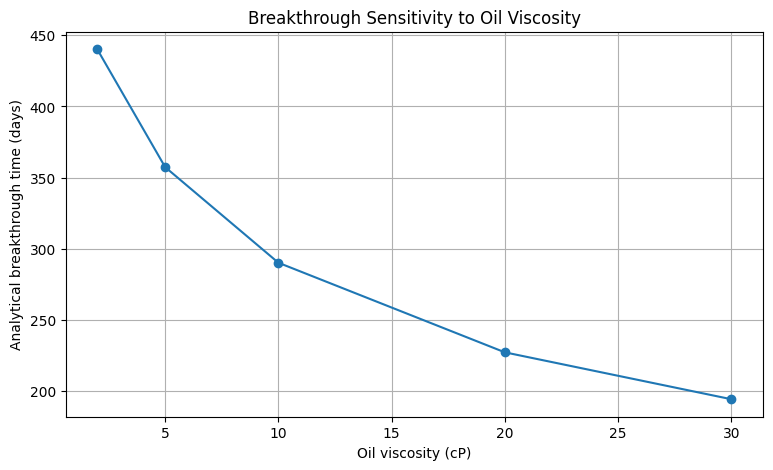

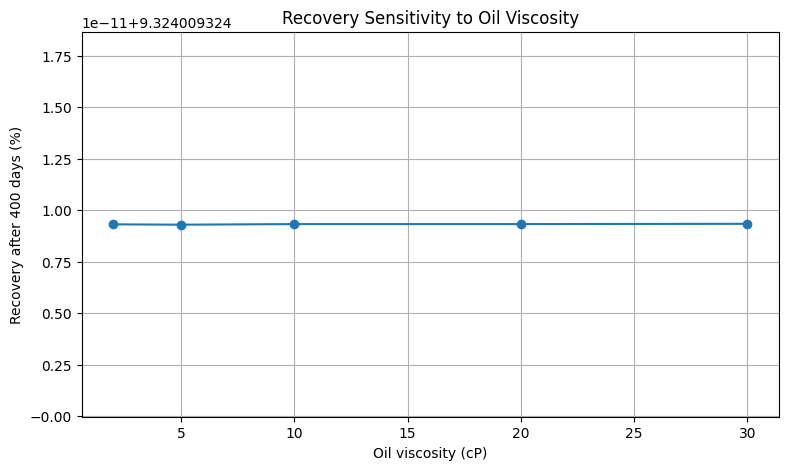

In [15]:
fig, ax = plt.subplots()
ax.plot(
    viscosity_sensitivity["Oil viscosity_cP"],
    viscosity_sensitivity["Analytical_BT_days"],
    marker="o"
)
ax.set_xlabel("Oil viscosity (cP)")
ax.set_ylabel("Analytical breakthrough time (days)")
ax.set_title("Breakthrough Sensitivity to Oil Viscosity")
plt.show()

fig, ax = plt.subplots()
ax.plot(
    viscosity_sensitivity["Oil viscosity_cP"],
    viscosity_sensitivity["Recovery_at_400d_percent"],
    marker="o"
)
ax.set_xlabel("Oil viscosity (cP)")
ax.set_ylabel("Recovery after 400 days (%)")
ax.set_title("Recovery Sensitivity to Oil Viscosity")
plt.show()

## 13. Sensitivity study: water viscosity and mobility control

Changing water viscosity changes water mobility:

\[
\lambda_w=\frac{k_{rw}}{\mu_w}
\]

We compare several water viscosities while keeping oil viscosity fixed.

Increasing water viscosity reduces water mobility and changes the fractional-flow curve. In real waterflood design, polymer flooding can deliberately increase injected-water viscosity to improve mobility control, although a polymer flood involves additional physics not modeled here.

In [16]:
water_viscosities = [0.5, 1.0, 2.0, 3.0]
water_rows = []

for muw in water_viscosities:
    Swf_w, fwf_w, pvbt_w, tbt_w, M_w = analytical_shock_properties(mu_o, muw)
    sim_w = simulate_waterflood(mu_w_value=muw, t_end=400.0)

    bt_idx = np.where(sim_w["water_cut"] >= 0.01)[0]
    bt_num = sim_w["times"][bt_idx[0]] if len(bt_idx) else np.nan

    water_rows.append({
        "Water viscosity_cP": muw,
        "Shock_Sw": Swf_w,
        "Shock_fw": fwf_w,
        "Breakthrough_PV": pvbt_w,
        "Analytical_BT_days": tbt_w,
        "Numerical_BT_days": bt_num,
        "Mobility_ratio": M_w,
        "Recovery_at_400d_percent": 100*sim_w["recovery"][-1]
    })

water_sensitivity = pd.DataFrame(water_rows)
water_sensitivity

,Water viscosity_cP,Shock_Sw,Shock_fw,Breakthrough_PV,Analytical_BT_days,Numerical_BT_days,Mobility_ratio,Recovery_at_400d_percent
0,0.5,0.365000,0.625000,0.232000,227.248442,NaN,1.666667,9.324009
1,1.0,0.418938,0.671499,0.296260,290.192616,NaN,2.044127,9.324009
2,2.0,0.486122,0.729416,0.364843,357.370739,NaN,2.695706,9.324009
3,3.0,0.530023,0.767261,0.404065,395.788927,NaN,3.296663,9.324009


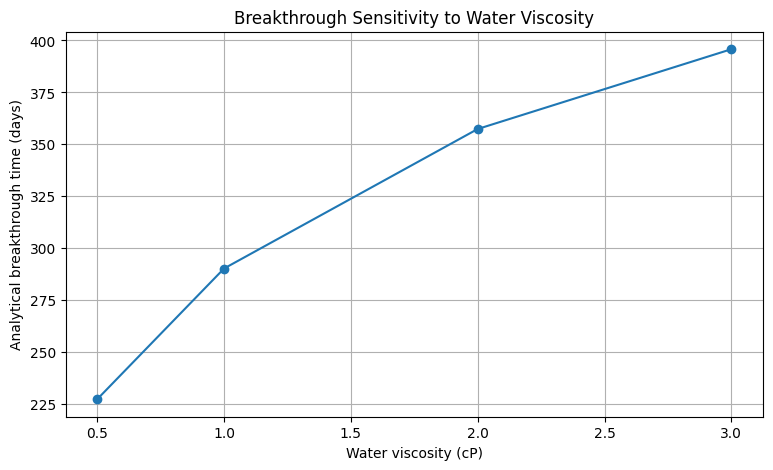

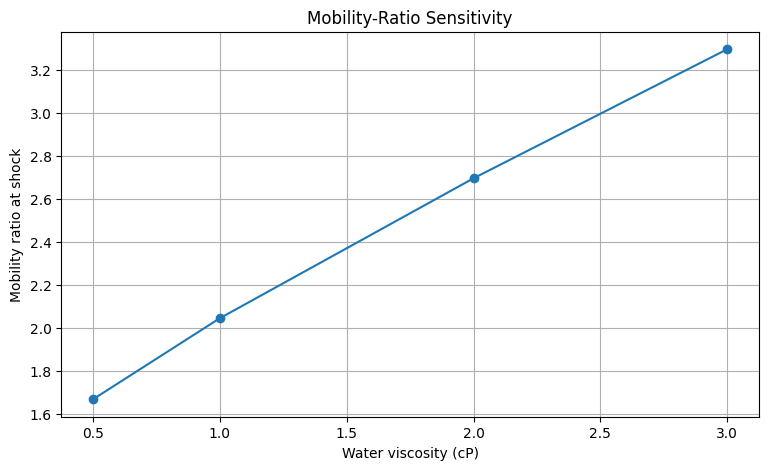

In [17]:
fig, ax = plt.subplots()
ax.plot(
    water_sensitivity["Water viscosity_cP"],
    water_sensitivity["Analytical_BT_days"],
    marker="o"
)
ax.set_xlabel("Water viscosity (cP)")
ax.set_ylabel("Analytical breakthrough time (days)")
ax.set_title("Breakthrough Sensitivity to Water Viscosity")
plt.show()

fig, ax = plt.subplots()
ax.plot(
    water_sensitivity["Water viscosity_cP"],
    water_sensitivity["Mobility_ratio"],
    marker="o"
)
ax.set_xlabel("Water viscosity (cP)")
ax.set_ylabel("Mobility ratio at shock")
ax.set_title("Mobility-Ratio Sensitivity")
plt.show()

## 14. Sensitivity study: relative-permeability shape

The Corey exponents determine the curvature of the relative-permeability functions.

We vary the water Corey exponent \(n_w\) while keeping the oil exponent fixed.

This demonstrates how rock-fluid interaction assumptions can alter fractional flow, shock saturation and breakthrough.

In [18]:
def make_fractional_flow_with_exponents(Sw_values, nw_value, no_value=n_o):
    Swn = normalized_sw(Sw_values)
    krw_v = krw_end * Swn**nw_value
    kro_v = kro_end * (1.0 - Swn)**no_value

    lw = krw_v / mu_w
    lo = kro_v / mu_o

    return lw / (lw + lo)

nw_values = [1.5, 2.0, 2.5, 3.0]
relperm_rows = []

for nw_value in nw_values:
    def fw_n(s):
        return float(make_fractional_flow_with_exponents(np.array([s]), nw_value)[0])

    def fw_n_prime(s, h=1e-5):
        return (fw_n(s+h) - fw_n(s-h))/(2*h)

    def shock_eq_n(s):
        return fw_n_prime(s) - fw_n(s)/(s-Swi)

    Sw_grid = np.linspace(Swi + 1e-4, 1-Sor-1e-4, 1000)
    eq_grid = np.array([shock_eq_n(s) for s in Sw_grid])

    roots_n = []
    for j in range(len(Sw_grid)-1):
        if eq_grid[j] * eq_grid[j+1] < 0:
            roots_n.append(brentq(shock_eq_n, Sw_grid[j], Sw_grid[j+1]))

    Swf_n = roots_n[0]
    fwf_n = fw_n(Swf_n)
    pvbt_n = (Swf_n-Swi)/fwf_n
    tbt_n = pvbt_n * PV_rb / q_inj

    relperm_rows.append({
        "Water Corey exponent": nw_value,
        "Shock_Sw": Swf_n,
        "Shock_fw": fwf_n,
        "Breakthrough_PV": pvbt_n,
        "Analytical_BT_days": tbt_n
    })

relperm_sensitivity = pd.DataFrame(relperm_rows)
relperm_sensitivity

,Water Corey exponent,Shock_Sw,Shock_fw,Breakthrough_PV,Analytical_BT_days
0,1.5,0.332096,0.494730,0.226580,221.939035
1,2.0,0.418938,0.671499,0.296260,290.192616
2,2.5,0.475204,0.754389,0.338293,331.364345
3,3.0,0.514698,0.802600,0.367179,359.658502


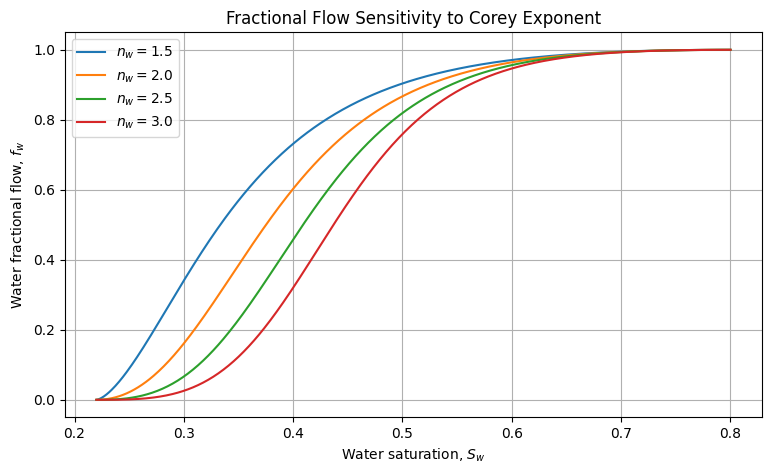

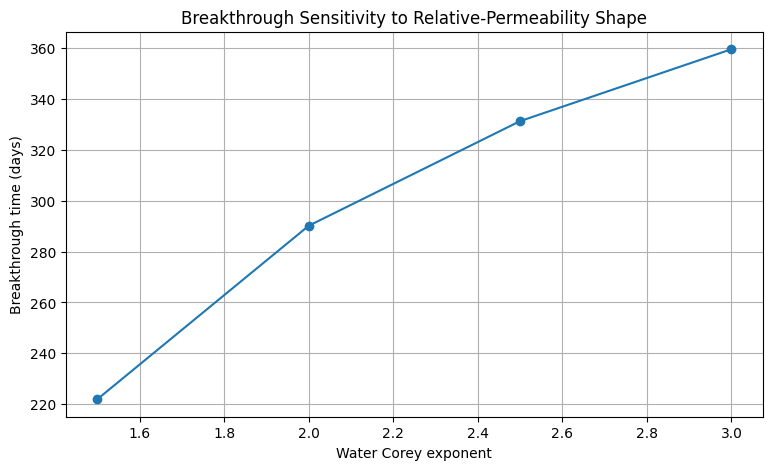

In [19]:
fig, ax = plt.subplots()
for nw_value in nw_values:
    fw_curve = make_fractional_flow_with_exponents(Sw, nw_value)
    ax.plot(Sw, fw_curve, label=fr"$n_w={nw_value}$")

ax.set_xlabel("Water saturation, $S_w$")
ax.set_ylabel(r"Water fractional flow, $f_w$")
ax.set_title("Fractional Flow Sensitivity to Corey Exponent")
ax.legend()
plt.show()

fig, ax = plt.subplots()
ax.plot(
    relperm_sensitivity["Water Corey exponent"],
    relperm_sensitivity["Analytical_BT_days"],
    marker="o"
)
ax.set_xlabel("Water Corey exponent")
ax.set_ylabel("Breakthrough time (days)")
ax.set_title("Breakthrough Sensitivity to Relative-Permeability Shape")
plt.show()

## 15. Recovery ceiling and field-performance interpretation

Under the incompressible 1-D assumptions, the maximum mobile-oil displacement recovery is

\[
RF_{max}
=
\frac{1-S_{wi}-S_{or}}
{1-S_{wi}}
\]

This is an idealized displacement limit. Real reservoirs may recover substantially less because of:

- heterogeneity
- gravity segregation
- viscous fingering
- capillary trapping
- incomplete sweep
- well-pattern effects
- fractures and high-permeability streaks
- changing fluid properties
- operational constraints

The present model intentionally isolates the fractional-flow and displacement physics.

In [20]:
RF_max = (1.0 - Swi - Sor) / (1.0 - Swi)

print(f"Idealized mobile-oil recovery ceiling = {100*RF_max:.2f}%")
print(f"Base-case recovery after 400 days    = {100*base['recovery'][-1]:.2f}%")

if np.isfinite(numerical_bt_days):
    print(f"Numerical breakthrough occurs at      = {numerical_bt_days:.1f} days")
print(f"Analytical breakthrough occurs at     = {t_BT_days:.1f} days")
print(f"Shock mobility ratio                  = {M_shock:.2f}")

Idealized mobile-oil recovery ceiling = 74.36%
Base-case recovery after 400 days    = 9.32%
Analytical breakthrough occurs at     = 290.2 days
Shock mobility ratio                  = 2.04


# Final Engineering Summary

### What was implemented

This project builds a complete computational waterflood workflow:

\[
\boxed{
k_{r\alpha}
\rightarrow
\lambda_\alpha
\rightarrow
f_w
\rightarrow
S_{wf}
\rightarrow
PV_{BT}
\rightarrow
S_w(x,t)
\rightarrow
WC(t)
\rightarrow
Recovery
}
\]

### Main reservoir-engineering concepts demonstrated

- Relative permeability
- Effective phase mobility
- Fractional-flow theory
- Buckley–Leverett shock analysis
- Analytical water-breakthrough estimation
- Numerical finite-volume saturation simulation
- Water-cut and oil-rate prediction
- Mobility-ratio analysis
- Sensitivity to oil viscosity
- Sensitivity to water viscosity
- Sensitivity to relative-permeability shape

### Limitations

This is an educational 1-D model. It does not represent a full-field reservoir simulator and deliberately excludes gravity, capillary pressure, heterogeneity, compressibility, multiphase PVT, wellbore effects and complex well patterns.

The synthetic data and parameters are therefore suitable for demonstrating reservoir-engineering reasoning and computational implementation, but not for field-development decisions.